In [1]:
import importlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from results import get_result
from tex import tex_gen_file

import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

In [2]:
X_TF_activities_broad = pd.read_csv("../../data/X_TFactivities_Broad.csv")
X_broad = X_TF_activities_broad.pivot(values="TF activity score", index="sample", columns=["gene"])
y_broad = pd.read_csv("../../data/Y_PDL1expression_Broad.csv", index_col="sample")["PDL1 expression"]
Xy_broad = X_broad.join(y_broad)
Xy_broad.head()


,AR,FOS,FOSL1,FOXO1,GATA2,IRF1,MYC,NFATC1,NFKB1,RELA,SOX2,SPI1,STAT1,STAT2,STAT3,STAT4,STAT6,TBX21,PDL1 expression
sample,,,,,,,,,,,,,,,,,,,
SIDM00001,-3.541276,-0.330966,-0.423200,0.510541,0.107477,5.030097,-0.172900,1.333479,4.302539,3.084642,-0.911085,6.194435,2.809228,0.847982,-1.112059,2.089240,0.332944,3.859296,-0.050474
SIDM00005,-3.987647,-2.830855,0.704617,-1.931544,-1.384505,-1.542503,-6.123899,-1.115811,-2.922073,-3.595709,-0.818795,-2.255999,-2.875264,-1.392960,-2.582800,-0.725619,-0.008506,-0.873064,-0.248723
SIDM00008,-1.883773,2.343044,0.698489,0.518416,1.954996,0.978567,-6.534764,1.242436,4.513697,3.999274,2.783495,1.632235,-1.995232,1.948572,1.731846,1.712673,1.346131,1.031253,-0.052154
SIDM00011,-1.058458,1.624131,-0.786086,-0.078463,3.160723,-0.085951,-6.797443,4.076593,-0.185916,-0.127614,0.327426,2.338943,-0.450481,0.236227,-1.039279,0.925985,1.163530,1.095876,-0.230074
SIDM00015,-2.535377,-0.314842,0.275515,-0.240138,-0.871939,1.406169,-7.473478,-1.418844,0.882683,0.498863,0.269346,-1.055084,-0.067370,2.081881,-0.162005,0.091977,2.924677,-0.347223,-0.212937


In [3]:
model_list = pd.read_csv("../../data/large/model_list_20260303.csv")
model_list.set_index("model_id", inplace=True)
model_list.info()

<class 'pandas.DataFrame'>
Index: 2266 entries, SIDM01774 to SIDM02271
Data columns (total 95 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   sample_id                                                      2266 non-null   str    
 1   patient_id                                                     2266 non-null   str    
 2   parent_id                                                      120 non-null    str    
 3   model_name                                                     2266 non-null   str    
 4   synonyms                                                       473 non-null    str    
 5   tissue                                                         2266 non-null   str    
 6   cancer_type                                                    2266 non-null   str    
 7   cancer_type_ncit_id                                            

In [4]:
df_broad = Xy_broad.join(model_list[["cancer_type", "tissue_status"]])
df_broad.info()

<class 'pandas.DataFrame'>
Index: 849 entries, SIDM00001 to SIDM01873
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AR               849 non-null    float64
 1   FOS              849 non-null    float64
 2   FOSL1            849 non-null    float64
 3   FOXO1            849 non-null    float64
 4   GATA2            849 non-null    float64
 5   IRF1             849 non-null    float64
 6   MYC              849 non-null    float64
 7   NFATC1           849 non-null    float64
 8   NFKB1            849 non-null    float64
 9   RELA             849 non-null    float64
 10  SOX2             849 non-null    float64
 11  SPI1             849 non-null    float64
 12  STAT1            849 non-null    float64
 13  STAT2            849 non-null    float64
 14  STAT3            849 non-null    float64
 15  STAT4            849 non-null    float64
 16  STAT6            849 non-null    float64
 17  TBX21            8

In [5]:
df_broad["tissue_status"].value_counts()

tissue_status
Tumour        507
Metastasis    272
Unknown        68
Normal          1
Papiloma        1
Name: count, dtype: int64

In [6]:
X_TF_activities_sanger = pd.read_csv("../../data/X_TFactivities_Sanger.csv")
X_sanger= X_TF_activities_sanger.pivot(values="TF activity score", index="sample", columns=["gene"])
y_sanger = pd.read_csv("../../data/Y_PDL1expression_Sanger.csv", index_col="sample")["PDL1 expression"]
Xy_sanger = X_sanger.join(y_sanger)
Xy_sanger.head()
df_sanger = Xy_sanger.join(model_list[["cancer_type", "tissue_status"]])
df_sanger.info()

<class 'pandas.DataFrame'>
Index: 442 entries, SIDM00002 to SIDM01483
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AR               442 non-null    float64
 1   FOS              442 non-null    float64
 2   FOSL1            442 non-null    float64
 3   FOXO1            442 non-null    float64
 4   GATA2            442 non-null    float64
 5   IRF1             442 non-null    float64
 6   MYC              442 non-null    float64
 7   NFATC1           442 non-null    float64
 8   NFKB1            442 non-null    float64
 9   RELA             442 non-null    float64
 10  SOX2             442 non-null    float64
 11  SPI1             442 non-null    float64
 12  STAT1            442 non-null    float64
 13  STAT2            442 non-null    float64
 14  STAT3            442 non-null    float64
 15  STAT4            442 non-null    float64
 16  STAT6            442 non-null    float64
 17  TBX21            4

In [7]:
df_broad["dataset"] = "Broad"
df_sanger["dataset"] = "Sanger"
df_combined = pd.concat([df_broad, df_sanger])
df_combined.info()

<class 'pandas.DataFrame'>
Index: 1291 entries, SIDM00001 to SIDM01483
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AR               1291 non-null   float64
 1   FOS              1291 non-null   float64
 2   FOSL1            1291 non-null   float64
 3   FOXO1            1291 non-null   float64
 4   GATA2            1291 non-null   float64
 5   IRF1             1291 non-null   float64
 6   MYC              1291 non-null   float64
 7   NFATC1           1291 non-null   float64
 8   NFKB1            1291 non-null   float64
 9   RELA             1291 non-null   float64
 10  SOX2             1291 non-null   float64
 11  SPI1             1291 non-null   float64
 12  STAT1            1291 non-null   float64
 13  STAT2            1291 non-null   float64
 14  STAT3            1291 non-null   float64
 15  STAT4            1291 non-null   float64
 16  STAT6            1291 non-null   float64
 17  TBX21            

In [8]:
pivot = pd.crosstab(
    df_combined["dataset"],
    df_combined["tissue_status"],
    margins=True,
    margins_name="Total",
    rownames=["Dataset"],
    colnames=["Tissue status"]
)
order = ["Tumour", "Metastasis", "Papiloma", "Normal", "Unknown"]
pivot = pivot.reindex(columns=order + ["Total"])
pivot.to_latex(tex_gen_file("data/counts.tex", root="../../"), bold_rows=True)
print(pivot.to_latex())

\begin{tabular}{lrrrrrr}
\toprule
Tissue status & Tumour & Metastasis & Papiloma & Normal & Unknown & Total \\
Dataset &  &  &  &  &  &  \\
\midrule
Broad & 507 & 272 & 1 & 1 & 68 & 849 \\
Sanger & 240 & 113 & 0 & 6 & 83 & 442 \\
Total & 747 & 385 & 1 & 7 & 151 & 1291 \\
\bottomrule
\end{tabular}



In [9]:
df_broad = df_broad[~df_broad["tissue_status"].isin(["Normal", "Papiloma"])]
df_broad["tissue_status"] = df_broad["tissue_status"].replace("Tumour", "Tumor")

In [10]:
df_broad.groupby("tissue_status")["PDL1 expression"].agg(["mean", "std"])

,mean,std
tissue_status,,
Metastasis,-0.133036,0.342162
Tumor,-0.116486,0.323597
Unknown,-0.097729,0.255372


In [11]:
col_names = [r"\makecell{Mean}",
             r"\makecell{Std.}",
             r"\makecell{Min.}",
             r"\makecell{25\%\\quantile}",
             r"\makecell{50\%\\quantile}",
             r"\makecell{75\%\\quantile}",
             r"\makecell{Max.}"]
col_names = [f"\\textbf{{{c}}}" for c in col_names]
cols = ["mean", "std", "min", "25%", "50%", "75%", "max"]

broad_descr = Xy_broad.describe().transpose()[cols]
sanger_descr = Xy_sanger.describe().transpose()[cols]

for df_descr in [broad_descr, sanger_descr]:
    df_descr.columns = col_names
    df_descr.rename(index={"PDL1 expression": r"\makecell[l]{PDL1\\expression}"}, inplace=True)
    df_descr.index = [f"\\textbf{{{i}}}" for i in df_descr.index]
    df_descr.index.name = r"\textbf{Gene}"
    df_descr.columns.name = r"\textbf{Activity}"

broad_descr = broad_descr.rename(index={"PDL1 expression": r"\makecell{PDL1\\expression}"})

print(broad_descr.to_latex(float_format="%.2f"))
broad_descr.to_latex(tex_gen_file("data/descr_broad.tex", root="../../"), float_format="%.2f")

print(sanger_descr.to_latex(float_format="%.2f"))
sanger_descr.to_latex(tex_gen_file("data/descr_sanger.tex", root="../../"), float_format="%.2f")



\begin{tabular}{lrrrrrrr}
\toprule
\textbf{Activity} & \textbf{\makecell{Mean}} & \textbf{\makecell{Std.}} & \textbf{\makecell{Min.}} & \textbf{\makecell{25\%\\quantile}} & \textbf{\makecell{50\%\\quantile}} & \textbf{\makecell{75\%\\quantile}} & \textbf{\makecell{Max.}} \\
\textbf{Gene} &  &  &  &  &  &  &  \\
\midrule
\textbf{AR} & -1.55 & 1.72 & -5.33 & -2.75 & -1.84 & -0.67 & 8.04 \\
\textbf{FOS} & 0.29 & 1.87 & -3.81 & -0.98 & 0.01 & 1.33 & 9.63 \\
\textbf{FOSL1} & 0.18 & 1.02 & -3.89 & -0.41 & -0.04 & 0.58 & 7.08 \\
\textbf{FOXO1} & -0.10 & 1.09 & -2.97 & -0.87 & -0.24 & 0.55 & 4.97 \\
\textbf{GATA2} & 0.57 & 1.46 & -2.23 & -0.31 & 0.31 & 1.11 & 9.69 \\
\textbf{IRF1} & 0.27 & 1.67 & -3.98 & -0.88 & 0.01 & 1.11 & 12.14 \\
\textbf{MYC} & -4.73 & 3.32 & -14.67 & -7.09 & -4.81 & -2.54 & 5.55 \\
\textbf{NFATC1} & 0.39 & 1.41 & -3.60 & -0.53 & 0.13 & 1.03 & 10.30 \\
\textbf{NFKB1} & 0.65 & 2.28 & -4.27 & -0.87 & 0.35 & 1.97 & 11.18 \\
\textbf{RELA} & 0.35 & 2.36 & -4.24 & -1.33 & 0.03 

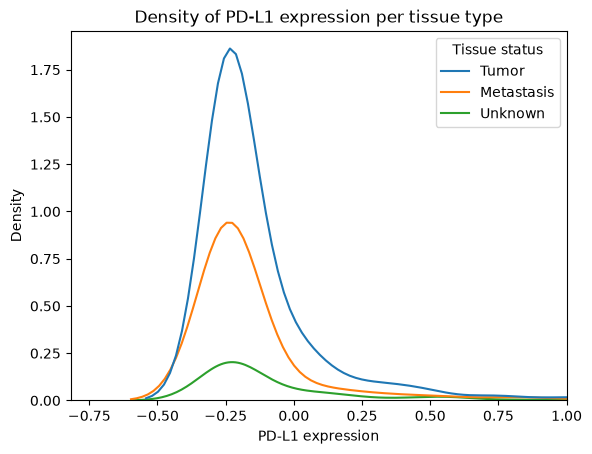

In [12]:
ax = sns.kdeplot(
    data=df_broad,
    x="PDL1 expression",
    hue="tissue_status",
    bw_adjust=1
)
ax.get_legend().set_title("Tissue status")
ax.set_xlim(None,1)
ax.set_xlabel("PD-L1 expression")
ax.set_title("Density of PD-L1 expression per tissue type")
plt.savefig(tex_gen_file("data/tissue_type_density_broad.svg", root="../../"))

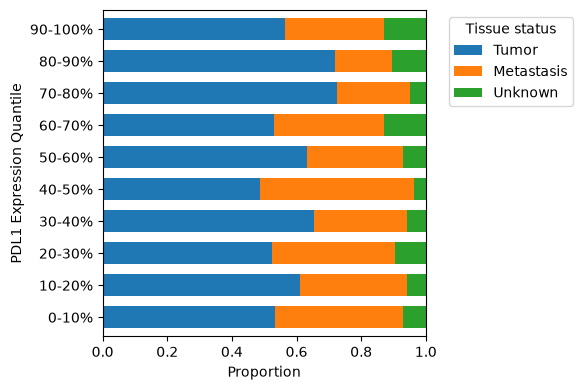

In [13]:
# Create decile bins
quantiles = np.linspace(0, 1, 11)
bin_labels = [f"{int(q1*100)}-{int(q2*100)}%" for q1, q2 in zip(quantiles[:-1], quantiles[1:])]

df_broad["PDL1_bin"] = pd.cut(
    df_broad["PDL1 expression"],
    bins=np.quantile(df_broad["PDL1 expression"], quantiles),
    labels=bin_labels,
    include_lowest=True
)

# Cross-tabulate and normalize to proportions
ct = pd.crosstab(df_broad["PDL1_bin"], df_broad["tissue_status"], normalize='index')
tissue_order = ["Tumor", "Metastasis", "Unknown"]
ct = ct[tissue_order]

# Stacked horizontal bar plot
ax = ct.plot(kind="barh", stacked=True, figsize=(6, 4), width=0.7)
ax.set_xlabel("Proportion")
ax.set_ylabel("PDL1 Expression Quantile")
ax.legend(title="Tissue status", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(tex_gen_file("data/tissue_type_quantile_broad.svg", root="../../"))

In [14]:
X_broad_tumour = df_broad[df_broad["tissue_status"] == "Tumor"][X_broad.columns].copy()
y_broad_tumour = df_broad[df_broad["tissue_status"] == "Tumor"][y_broad.name].copy()
X_broad_metastasis = df_broad[df_broad["tissue_status"] == "Metastasis"][X_broad.columns].copy()
y_broad_metastasis = df_broad[df_broad["tissue_status"] == "Metastasis"][y_broad.name].copy()

In [15]:
from py.greedy import solve_greedy, save_greedy_result_latex

greedy_idxs = [
    {
        "yq": 4,
        "C": 3,
        "D": 2,
        "mw": 0
    },
    {
        "yq": 5,
        "C": 3,
        "D": 2,
        "mw": 0
    },
]

for X, y, type in [
    (X_broad_tumour, y_broad_tumour, "tumor"),
    (X_broad_metastasis, y_broad_metastasis, "metastasis"),
]:
    for idx in greedy_idxs:
        y_q = (y >= y.quantile((idx["yq"] + 1)/10)).astype(int)
        ruleset, df = solve_greedy(X, y_q, C=idx["C"], D=idx["D"], beta=idx["mw"], n_quantiles=9)

        save_greedy_result_latex(ruleset, df,
                                 tex_gen_file("PDL1ex2/tab_greedy_type_{t}_yq_{yq}_mw_{mw}_C_{C}_D_{D}.tex".format(t=type, **idx), root="../../"))


--- Starting iteration 0. 508.0
Intermediate dataset has 507 points (254 pos, 253 neg)
Base objective 508.00


162567it [00:14, 11474.52it/s]                                                  


['RELA>=-1.42186376538459', 'STAT2>=-0.4240632312987188']
Newly found rule:  [RELA >= -1.422 Q(0.201), STAT2 >= -0.424 Q(0.400)]
Positively classifies 289 more points (fraction 0.57 of total).
This is 203 positive points of total 254 positive points.
Objective after: 274.0
Total accuracy up until now:  0.7297830374753451
--- Starting iteration 1. 102.0
Intermediate dataset has 218 points (51 pos, 167 neg)
Base objective 102.00


162567it [00:12, 13322.87it/s]                                                  


['AR>=-1.4552746469114748', 'FOSL1>=0.5204628096026641']
Newly found rule:  [AR >= -1.455 Q(0.697), FOSL1 >= 0.520 Q(0.899)]
Positively classifies 12 more points (fraction 0.02 of total).
This is 9 positive points of total 51 positive points.
Objective after: 90.0
Total accuracy up until now:  0.7416173570019724
--- Starting iteration 2. 84.0
Intermediate dataset has 206 points (42 pos, 164 neg)
Base objective 84.00


...

['FOSL1>=-0.057104833384181056', 'RELA>=0.009163757913057019']
Newly found rule:  [FOSL1 >= -0.057 Q(0.500), RELA >= 0.009 Q(0.599)]
Positively classifies 75 more points (fraction 0.28 of total).
This is 54 positive points of total 109 positive points.
Objective after: 152.0
Total accuracy up until now:  0.7205882352941176
--- Starting iteration 1. 110.0
Intermediate dataset has 197 points (55 pos, 142 neg)
Base objective 110.00


162567it [00:07, 23223.69it/s]                                                  


['GATA2>=-0.362062792323525', '-FOSL1>=0.7554361288793887']
Newly found rule:  [GATA2 >= -0.362 Q(0.401), FOSL1 <= -0.755 Q(0.102)]
Positively classifies 12 more points (fraction 0.04 of total).
This is 10 positive points of total 55 positive points.
Objective after: 94.0
Total accuracy up until now:  0.75
--- Starting iteration 2. 90.0
Intermediate dataset has 185 points (45 pos, 140 neg)
Base objective 90.00


162567it [00:06, 26116.39it/s]                                                  


['NFKB1>=-2.719344857025872', '-SPI1>=2.4306876231544976']
Newly found rule:  [NFKB1 >= -2.719 Q(0.103), SPI1 <= -2.431 Q(0.103)]
Positively classifies 6 more points (fraction 0.02 of total).
This is 6 positive points of total 45 positive points.
Objective after: 78.0
Total accuracy up until now:  0.7720588235294118
~ Finished.
Final objective: 124.0
Final accuracy: 0.7720588235294118


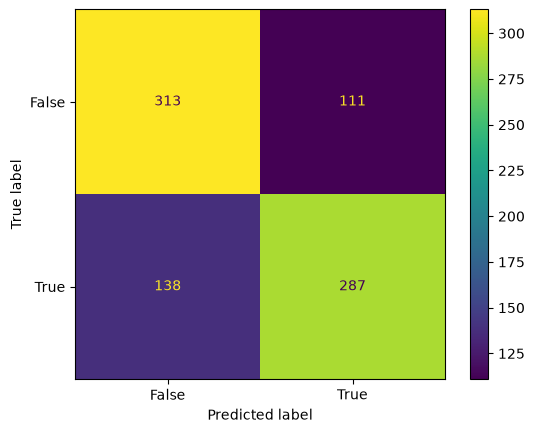

Index(['PDL1 expression>=-0.2380 Q(0.5000)'], dtype='str')
0.7067137809187279


In [16]:
from results import *

idx = {
    "yq": 4,
    "C": 1,
    "D": 2,
    "mw": 0
}
res = get_result("../../data/PDL1_experiment_2/results", r"yq_{yq}_mw_{mw}_C_{C}_settings_D_{D}.set.json", idx)
X, y = load_X_y(idx, "../../data/PDL1_experiment_2",
                filename_X_format="X_with_sample.csv",
                filename_y_format="y_q_{yq}_with_sample.csv")
y_cont = pd.read_csv("../../data/PDL1_experiment_2/y_with_sample.csv").set_index("sample")
X = X.set_index("sample")
y = y.set_index("sample")

ruleset = res["binary"]
ruleset_formatted = format_bare_ruleset(ruleset, X)

y_hat = predict_threshold(ruleset, X)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y.astype(bool), y_hat)
ConfusionMatrixDisplay(cm, display_labels=["False", "True"]).plot()
plt.show()

print(y.columns)
print(accuracy_score(y, y_hat))

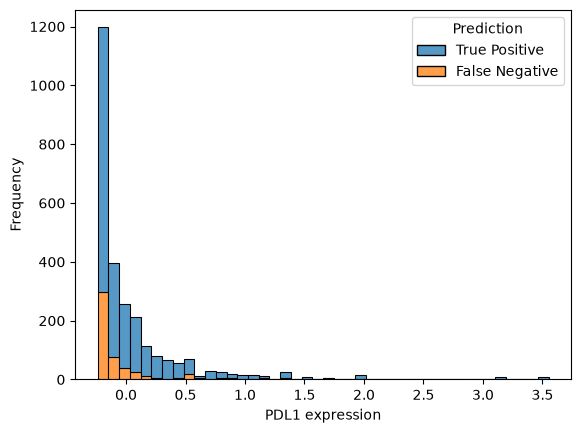

In [17]:


df = y_cont.loc[X.index].copy()
df["y_hat"] = y_hat
df["y_true"] = y.iloc[:, 0].values

pos_true = df[df["y_true"] == 1].copy()
pos_true["Prediction"] = pos_true["y_hat"].map({True: "True Positive", False: "False"
                                                                              " Negative"})

fig, ax = plt.subplots()
sns.histplot(data=pos_true, x="PDL1 expression", hue="Prediction", stat="frequency",
             multiple="stack", common_bins=True, ax=ax)
plt.show()

In [18]:
df = df_broad.copy()
df["y"] = y
df["y_hat"] = y_hat

def ratio(sub):
    counts = sub["tissue_status"].value_counts()
    print(counts)
    return counts.get("Tumor", 0) / counts.get("Metastasis", 0)

print("Predicted True — tumour/metastasis ratio:", ratio(df[df["y_hat"]]))
print("True Positives — tumour/metastasis ratio:", ratio(df[df["y"] == 1]))

tissue_status
Tumor         249
Metastasis    104
Unknown        43
Name: count, dtype: int64
Predicted True — tumour/metastasis ratio: 2.394230769230769
tissue_status
Tumor         268
Metastasis    114
Unknown        41
Name: count, dtype: int64
True Positives — tumour/metastasis ratio: 2.3508771929824563


In [19]:
X_broad_tpm = pd.read_csv("../../data/PDL1_experiment_3/X_broad_with_sample.csv").set_index("sample")
y_broad_tpm = pd.read_csv("../../data/PDL1_experiment_3/y_broad_with_sample.csv").set_index("sample")
Xy_broad = X_broad_TPM.join(y_broad_tpm)
df_tpm_broad = Xy_broad.join(model_list[["cancer_type", "tissue_status"]])
df_tpm_broad.info();

NameError: name 'X_broad_TPM' is not defined